# L1 vs L2 Lomb-Scargle Periodogram Comparison

Compare the robust L1 periodogram with astropy's standard (L2) Lomb-Scargle.

1. Gaussian noise: both methods should agree
2. Heavy-tailed noise (Student-t, df=1 = Cauchy): L1 should be robust, L2 should fail
3. Heteroscedastic errors: providing `dy` should improve recovery when measurement uncertainties vary

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle
from lombscargle_l1 import LombScargleL1

rng = np.random.default_rng(42)

## Generate the signal

True signal: two sinusoids at f=0.1 and f=0.23, sampled irregularly.

In [2]:
# Irregular time sampling: 400 points over [0, 200]
n_obs = 400
t = np.sort(rng.uniform(0, 200, n_obs))

# True signal
f1, f2 = 0.1, 0.23
a1, a2 = 3.0, 2.0
y_true = a1 * np.sin(2 * np.pi * f1 * t) + a2 * np.sin(2 * np.pi * f2 * t)

# Dense grid for plotting the true signal
t_dense = np.linspace(0, 200, 2000)
y_dense = a1 * np.sin(2 * np.pi * f1 * t_dense) + a2 * np.sin(2 * np.pi * f2 * t_dense)

## Case 1: Gaussian noise

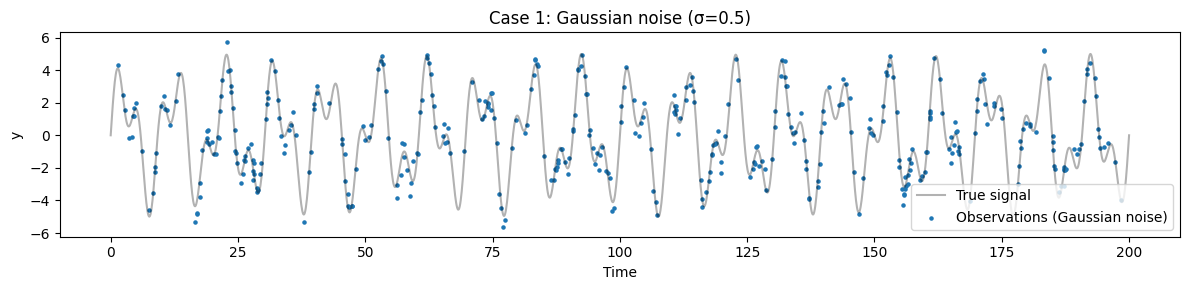

In [3]:
sigma_gauss = 0.5
noise_gauss = rng.normal(0, sigma_gauss, n_obs)
y_gauss = y_true + noise_gauss

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t_dense, y_dense, 'k-', alpha=0.3, label='True signal')
ax.scatter(t, y_gauss, s=5, c='C0', label='Observations (Gaussian noise)')
ax.set_xlabel('Time')
ax.set_ylabel('y')
ax.legend()
ax.set_title('Case 1: Gaussian noise (σ=0.5)')
plt.tight_layout()

/Users/alexey/pynotebooks/study/LombScargle_L1/lombscargle_l1.py:157: RuntimeWarning: divide by zero encountered in matmul
  return np.sum(np.abs(d - A @ x))
/Users/alexey/pynotebooks/study/LombScargle_L1/lombscargle_l1.py:157: RuntimeWarning: overflow encountered in matmul
  return np.sum(np.abs(d - A @ x))
/Users/alexey/pynotebooks/study/LombScargle_L1/lombscargle_l1.py:157: RuntimeWarning: invalid value encountered in matmul
  return np.sum(np.abs(d - A @ x))


L2 peak frequencies: [0.10025025 0.09975976]
L1 peak frequencies: [0.10025025 0.09975976]


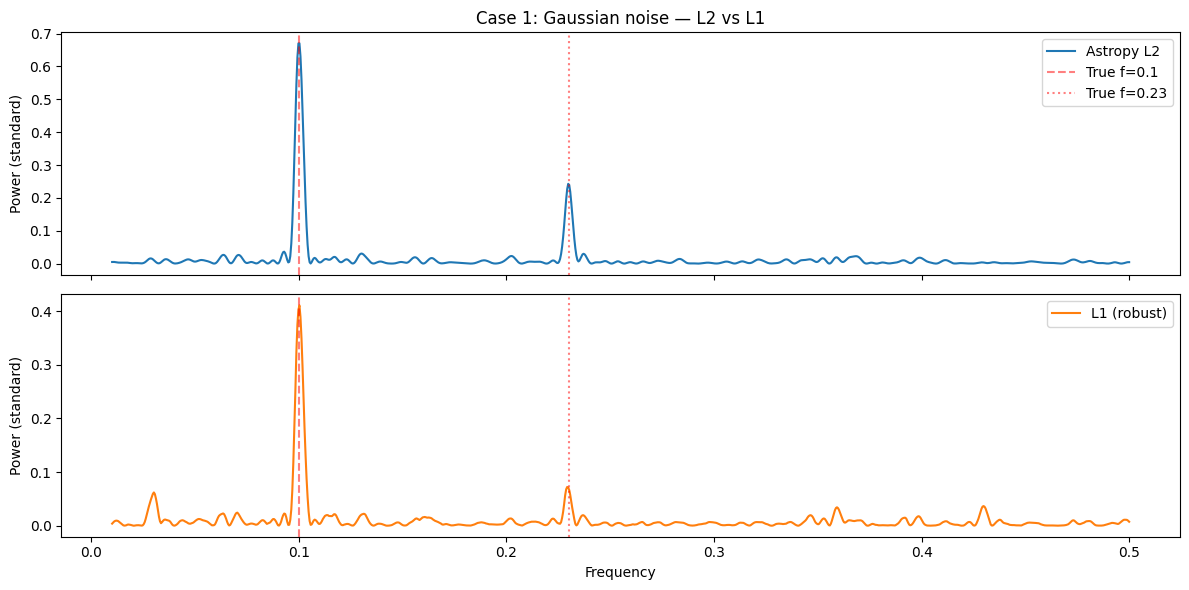

In [4]:
freq_grid = np.linspace(0.01, 0.5, 1000)

# Astropy L2
ls_l2 = LombScargle(t, y_gauss, fit_mean=True)
power_l2 = ls_l2.power(freq_grid, normalization='standard')

# L1
ls_l1 = LombScargleL1(t, y_gauss, fit_mean=True, fit_trend=True, normalization='standard')
power_l1 = ls_l1.power(freq_grid)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(freq_grid, power_l2, 'C0', label='Astropy L2')
axes[0].axvline(f1, color='r', ls='--', alpha=0.5, label=f'True f={f1}')
axes[0].axvline(f2, color='r', ls=':', alpha=0.5, label=f'True f={f2}')
axes[0].set_ylabel('Power (standard)')
axes[0].legend()
axes[0].set_title('Case 1: Gaussian noise — L2 vs L1')

axes[1].plot(freq_grid, power_l1, 'C1', label='L1 (robust)')
axes[1].axvline(f1, color='r', ls='--', alpha=0.5)
axes[1].axvline(f2, color='r', ls=':', alpha=0.5)
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Power (standard)')
axes[1].legend()

plt.tight_layout()

print(f'L2 peak frequencies: {freq_grid[np.argsort(power_l2)[-2:][::-1]]}')
print(f'L1 peak frequencies: {freq_grid[np.argsort(power_l1)[-2:][::-1]]}')

## Case 2: Heavy-tailed noise (Student-t, df=1 = Cauchy)

Points with |noise| > 3σ: 90/400 (22%)
Max |noise|: 189.5


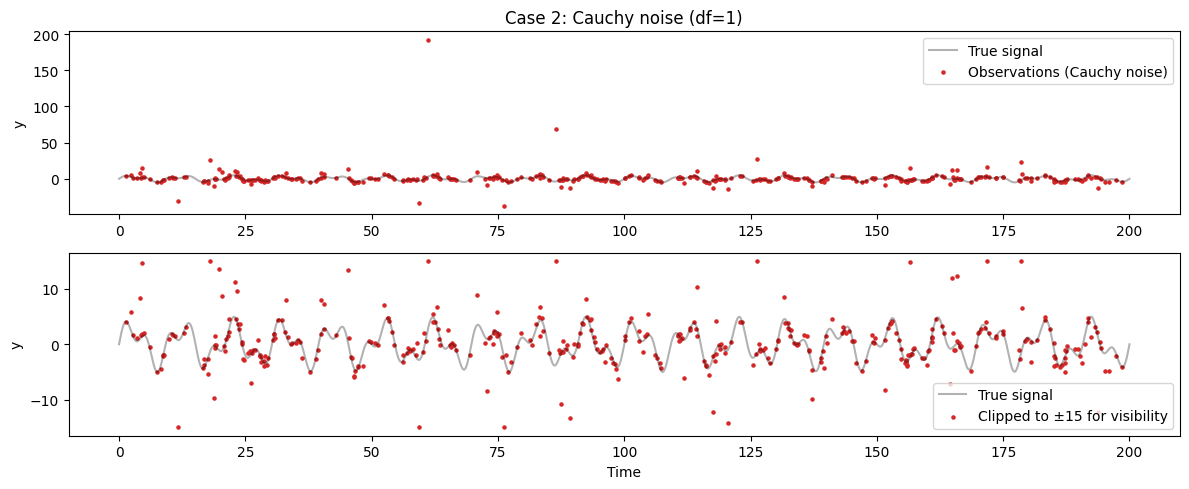

In [5]:
noise_cauchy = rng.standard_cauchy(n_obs) * sigma_gauss
y_cauchy = y_true + noise_cauchy

fig, axes = plt.subplots(2, 1, figsize=(12, 5))

axes[0].plot(t_dense, y_dense, 'k-', alpha=0.3, label='True signal')
axes[0].scatter(t, y_cauchy, s=5, c='C3', label='Observations (Cauchy noise)')
axes[0].set_ylabel('y')
axes[0].legend()
axes[0].set_title('Case 2: Cauchy noise (df=1)')

# Zoom in to see the signal structure
y_clip = np.clip(y_cauchy, -15, 15)
axes[1].plot(t_dense, y_dense, 'k-', alpha=0.3, label='True signal')
axes[1].scatter(t, y_clip, s=5, c='C3', label='Clipped to ±15 for visibility')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('y')
axes[1].legend()

n_outliers = np.sum(np.abs(y_cauchy - y_true) > 3 * sigma_gauss)
print(f'Points with |noise| > 3σ: {n_outliers}/{n_obs} ({100*n_outliers/n_obs:.0f}%)')
print(f'Max |noise|: {np.max(np.abs(noise_cauchy)):.1f}')
plt.tight_layout()

L2 peak frequencies: [0.22973974 0.09975976]
L1 peak frequencies: [0.10025025 0.09975976]


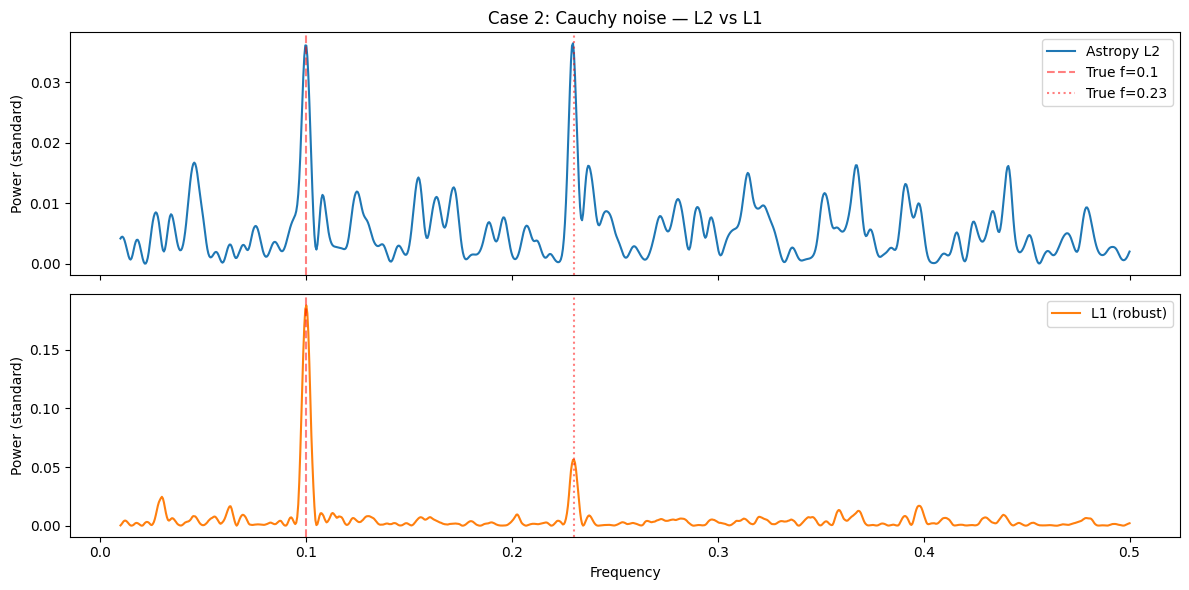

In [6]:
# Astropy L2
ls_l2_c = LombScargle(t, y_cauchy, fit_mean=True)
power_l2_c = ls_l2_c.power(freq_grid, normalization='standard')

# L1
ls_l1_c = LombScargleL1(t, y_cauchy, fit_mean=True, fit_trend=True, normalization='standard')
power_l1_c = ls_l1_c.power(freq_grid)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(freq_grid, power_l2_c, 'C0', label='Astropy L2')
axes[0].axvline(f1, color='r', ls='--', alpha=0.5, label=f'True f={f1}')
axes[0].axvline(f2, color='r', ls=':', alpha=0.5, label=f'True f={f2}')
axes[0].set_ylabel('Power (standard)')
axes[0].legend()
axes[0].set_title('Case 2: Cauchy noise — L2 vs L1')

axes[1].plot(freq_grid, power_l1_c, 'C1', label='L1 (robust)')
axes[1].axvline(f1, color='r', ls='--', alpha=0.5)
axes[1].axvline(f2, color='r', ls=':', alpha=0.5)
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Power (standard)')
axes[1].legend()

plt.tight_layout()

print(f'L2 peak frequencies: {freq_grid[np.argsort(power_l2_c)[-2:][::-1]]}')
print(f'L1 peak frequencies: {freq_grid[np.argsort(power_l1_c)[-2:][::-1]]}')

## Case 2b: More realistic ground-based sampling + Cauchy noise

The uniform random sampling above is a favorable case. Real observations have:
- **Seasonal gaps**: target visible ~6 months/year
- **Weather losses**: ~30% of nights lost randomly
- **Nightly cadence**: one observation per clear night

This creates a structured window function that introduces aliases and makes period recovery harder.

Observations: 397, spanning 909 days
Seasonal gaps: 2


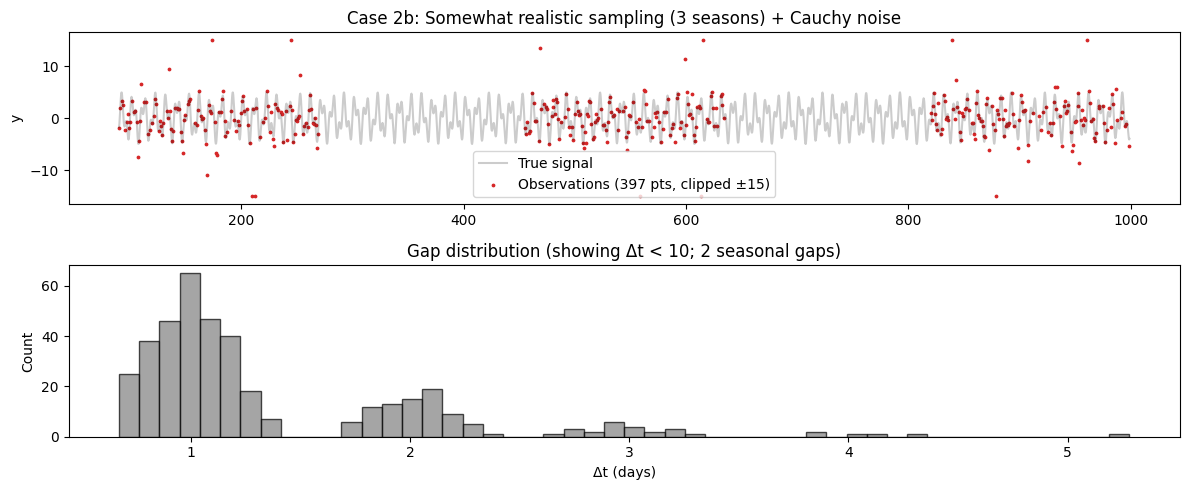

In [14]:
# Realistic ground-based sampling: 3 seasons, ~6 months visible, weather losses
t_real = []
for year in range(3):
    # Observing season: nights 90-270 of each 365-day year
    season_start = year * 365 + 90
    season_end = year * 365 + 270
    nights = np.arange(season_start, season_end, dtype=float)
    # Add small sub-night jitter (observation not always at same hour)
    nights += rng.uniform(-0.2, 0.2, len(nights))
    # Weather: keep ~70% of nights
    clear = rng.random(len(nights)) < 0.7
    t_real.append(nights[clear])

t_real = np.concatenate(t_real)
n_real = len(t_real)

# Same true signal + Cauchy noise
y_true_real = a1 * np.sin(2 * np.pi * f1 * t_real) + a2 * np.sin(2 * np.pi * f2 * t_real)
noise_real = rng.standard_cauchy(n_real) * sigma_gauss
y_real = y_true_real + noise_real

# Show the sampling pattern
fig, axes = plt.subplots(2, 1, figsize=(12, 5))

# Time series
y_clip_real = np.clip(y_real, -15, 15)
t_dense_real = np.linspace(t_real.min(), t_real.max(), 3000)
y_dense_real = a1 * np.sin(2 * np.pi * f1 * t_dense_real) + a2 * np.sin(2 * np.pi * f2 * t_dense_real)
axes[0].plot(t_dense_real, y_dense_real, 'k-', alpha=0.2, label='True signal')
axes[0].scatter(t_real, y_clip_real, s=3, c='C3', label=f'Observations ({n_real} pts, clipped ±15)')
axes[0].set_ylabel('y')
axes[0].legend()
axes[0].set_title('Case 2b: Somewhat realistic sampling (3 seasons) + Cauchy noise')

# Sampling density / gaps
dt_real = np.diff(t_real)
axes[1].hist(dt_real[dt_real < 10], bins=50, color='C7', edgecolor='k', alpha=0.7)
axes[1].set_xlabel('Δt (days)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Gap distribution (showing Δt < 10; {np.sum(dt_real >= 10)} seasonal gaps)')

plt.tight_layout()
print(f'Observations: {n_real}, spanning {t_real[-1]-t_real[0]:.0f} days')
print(f'Seasonal gaps: {np.sum(dt_real > 50)}')

L2 peak frequencies: [0.10013514 0.09765766]
L1 peak frequencies: [0.10013514 0.09963964]


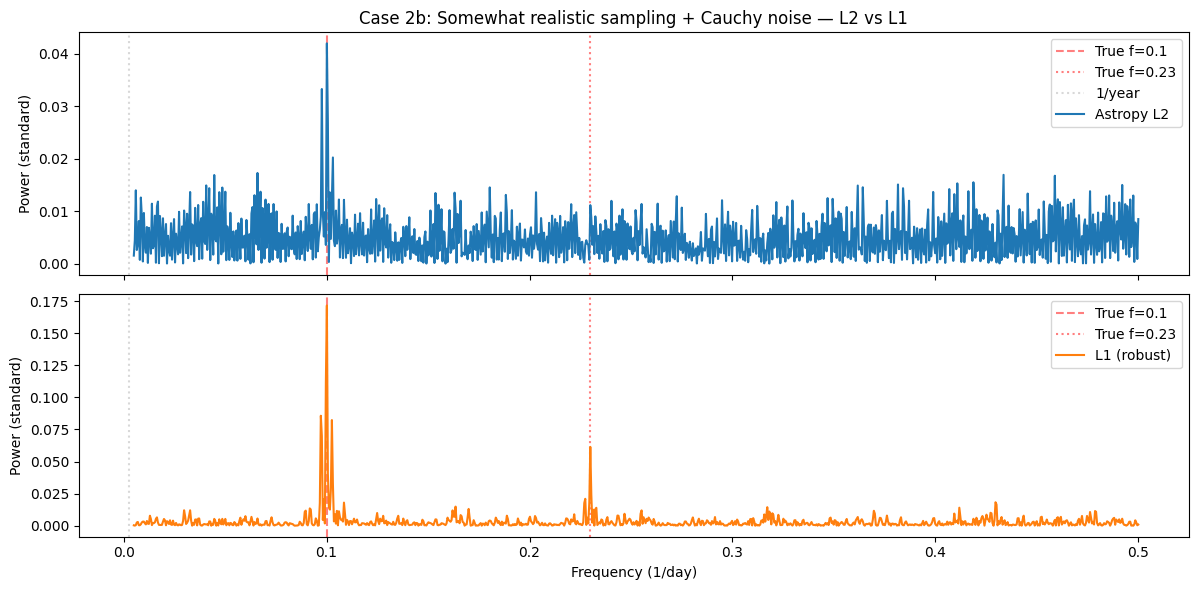

In [15]:
# Periodograms with realistic sampling
# Frequency grid: signal frequencies are 0.1 and 0.23 (periods 10 and 4.3 days)
# Expect aliases near f ± 1/365 (annual) and f ± 1 (daily)
freq_real = np.linspace(0.005, 0.5, 1000)

ls_l2_real = LombScargle(t_real, y_real, fit_mean=True)
power_l2_real = ls_l2_real.power(freq_real, normalization='standard')

ls_l1_real = LombScargleL1(t_real, y_real, fit_mean=True, fit_trend=True, normalization='standard')
power_l1_real = ls_l1_real.power(freq_real)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for ax in axes:
    ax.axvline(f1, color='r', ls='--', alpha=0.5, label=f'True f={f1}')
    ax.axvline(f2, color='r', ls=':', alpha=0.5, label=f'True f={f2}')
    # Mark annual alias: f_annual = 1/365 ≈ 0.00274
    ax.axvline(1/365, color='grey', ls=':', alpha=0.3, label='1/year' if ax is axes[0] else None)

axes[0].plot(freq_real, power_l2_real, 'C0', label='Astropy L2')
axes[0].set_ylabel('Power (standard)')
axes[0].legend()
axes[0].set_title('Case 2b: Somewhat realistic sampling + Cauchy noise — L2 vs L1')

axes[1].plot(freq_real, power_l1_real, 'C1', label='L1 (robust)')
axes[1].set_xlabel('Frequency (1/day)')
axes[1].set_ylabel('Power (standard)')
axes[1].legend()

plt.tight_layout()

print(f'L2 peak frequencies: {freq_real[np.argsort(power_l2_real)[-2:][::-1]]}')
print(f'L1 peak frequencies: {freq_real[np.argsort(power_l1_real)[-2:][::-1]]}')

## Case 3: Heteroscedastic errors (known measurement uncertainties)

Some observations are noisier than others. Both L2 and L1 accept `dy` to down-weight uncertain points.

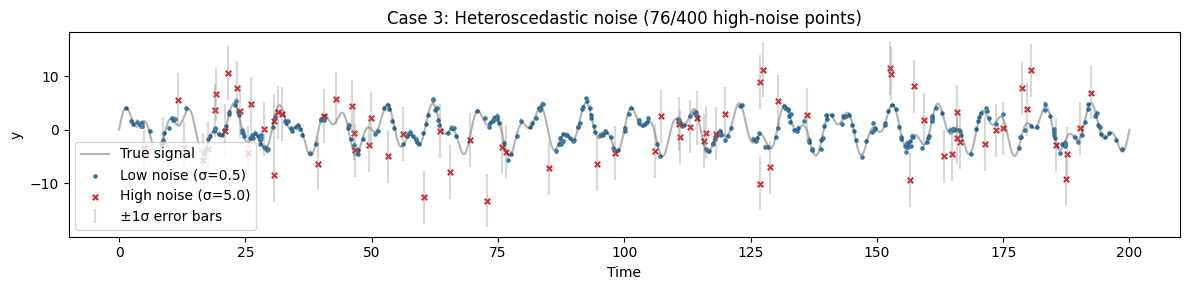

In [16]:
# Heteroscedastic errors: 20% of points have 10x larger uncertainty
dy = np.full(n_obs, sigma_gauss)
noisy_mask = rng.random(n_obs) < 0.2
dy[noisy_mask] = sigma_gauss * 10

noise_hetero = rng.normal(0, dy)
y_hetero = y_true + noise_hetero

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t_dense, y_dense, 'k-', alpha=0.3, label='True signal')
ax.errorbar(t, y_hetero, yerr=dy, fmt='none', ecolor='grey', alpha=0.3, label='±1σ error bars')
ax.scatter(t[~noisy_mask], y_hetero[~noisy_mask], s=5, c='C0', label=f'Low noise (σ={sigma_gauss})')
ax.scatter(t[noisy_mask], y_hetero[noisy_mask], s=15, c='C3', marker='x', label=f'High noise (σ={sigma_gauss*10})')
ax.set_xlabel('Time')
ax.set_ylabel('y')
ax.legend()
ax.set_title(f'Case 3: Heteroscedastic noise ({noisy_mask.sum()}/{n_obs} high-noise points)')
plt.tight_layout()

Peak frequencies (top 2):
  L2 no dy  : [0.10025025 0.09975976]
  L2 + dy   : [0.10025025 0.09975976]
  L1 no dy  : [0.10025025 0.09975976]
  L1 + dy   : [0.10025025 0.09975976]


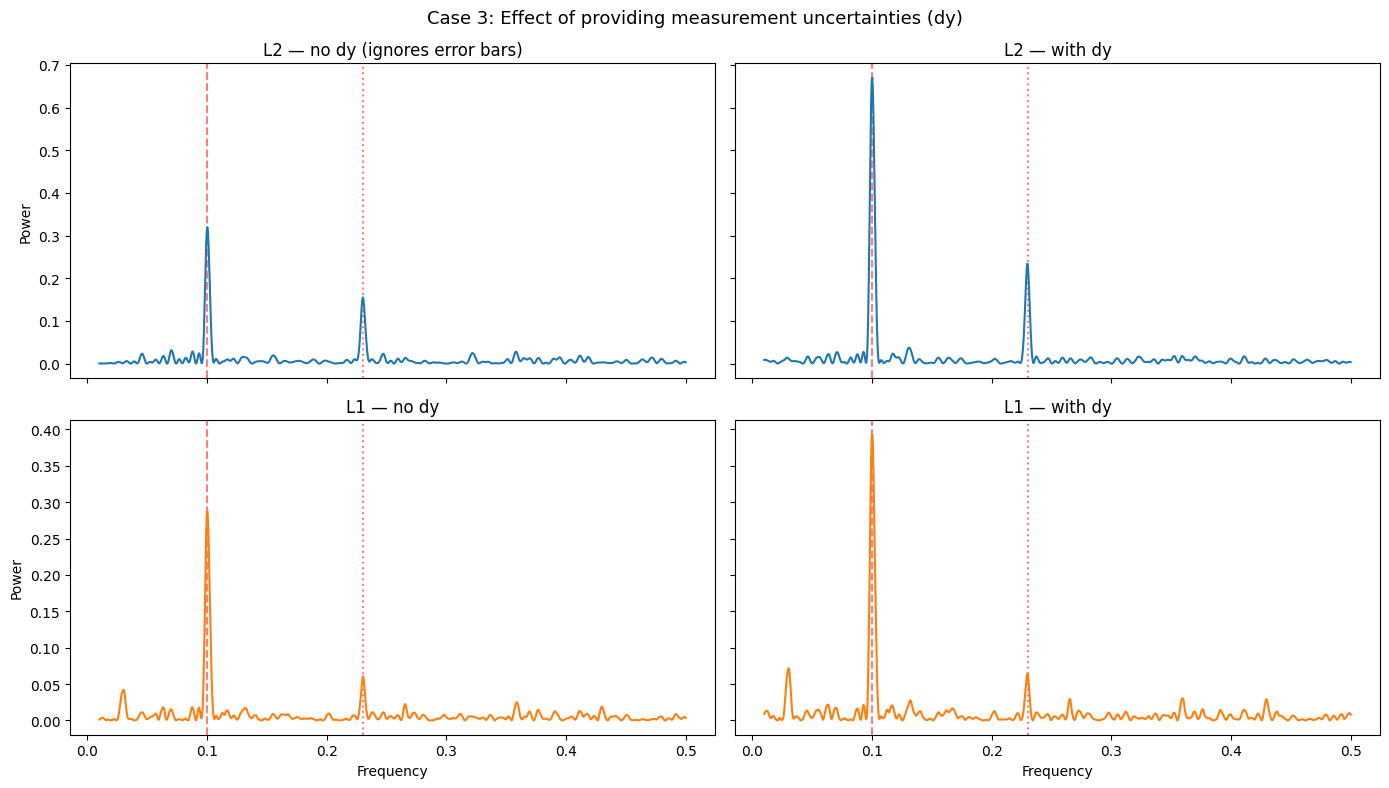

In [17]:
# With dy (weighted)
ls_l2_dy = LombScargle(t, y_hetero, dy, fit_mean=True)
power_l2_dy = ls_l2_dy.power(freq_grid, normalization='standard')

ls_l1_dy = LombScargleL1(t, y_hetero, dy=dy, fit_mean=True, fit_trend=True, normalization='standard')
power_l1_dy = ls_l1_dy.power(freq_grid)

# Without dy (unweighted) for comparison
ls_l2_nody = LombScargle(t, y_hetero, fit_mean=True)
power_l2_nody = ls_l2_nody.power(freq_grid, normalization='standard')

ls_l1_nody = LombScargleL1(t, y_hetero, fit_mean=True, fit_trend=True, normalization='standard')
power_l1_nody = ls_l1_nody.power(freq_grid)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey='row')

for ax in axes.flat:
    ax.axvline(f1, color='r', ls='--', alpha=0.5)
    ax.axvline(f2, color='r', ls=':', alpha=0.5)

axes[0, 0].plot(freq_grid, power_l2_nody, 'C0')
axes[0, 0].set_title('L2 — no dy (ignores error bars)')
axes[0, 0].set_ylabel('Power')

axes[0, 1].plot(freq_grid, power_l2_dy, 'C0')
axes[0, 1].set_title('L2 — with dy')

axes[1, 0].plot(freq_grid, power_l1_nody, 'C1')
axes[1, 0].set_title('L1 — no dy')
axes[1, 0].set_ylabel('Power')
axes[1, 0].set_xlabel('Frequency')

axes[1, 1].plot(freq_grid, power_l1_dy, 'C1')
axes[1, 1].set_title('L1 — with dy')
axes[1, 1].set_xlabel('Frequency')

fig.suptitle('Case 3: Effect of providing measurement uncertainties (dy)', fontsize=13)
plt.tight_layout()

print('Peak frequencies (top 2):')
for label, p in [('L2 no dy', power_l2_nody), ('L2 + dy', power_l2_dy),
                  ('L1 no dy', power_l1_nody), ('L1 + dy', power_l1_dy)]:
    peaks = freq_grid[np.argsort(p)[-2:][::-1]]
    print(f'  {label:10s}: {peaks}')

## Side-by-side summary

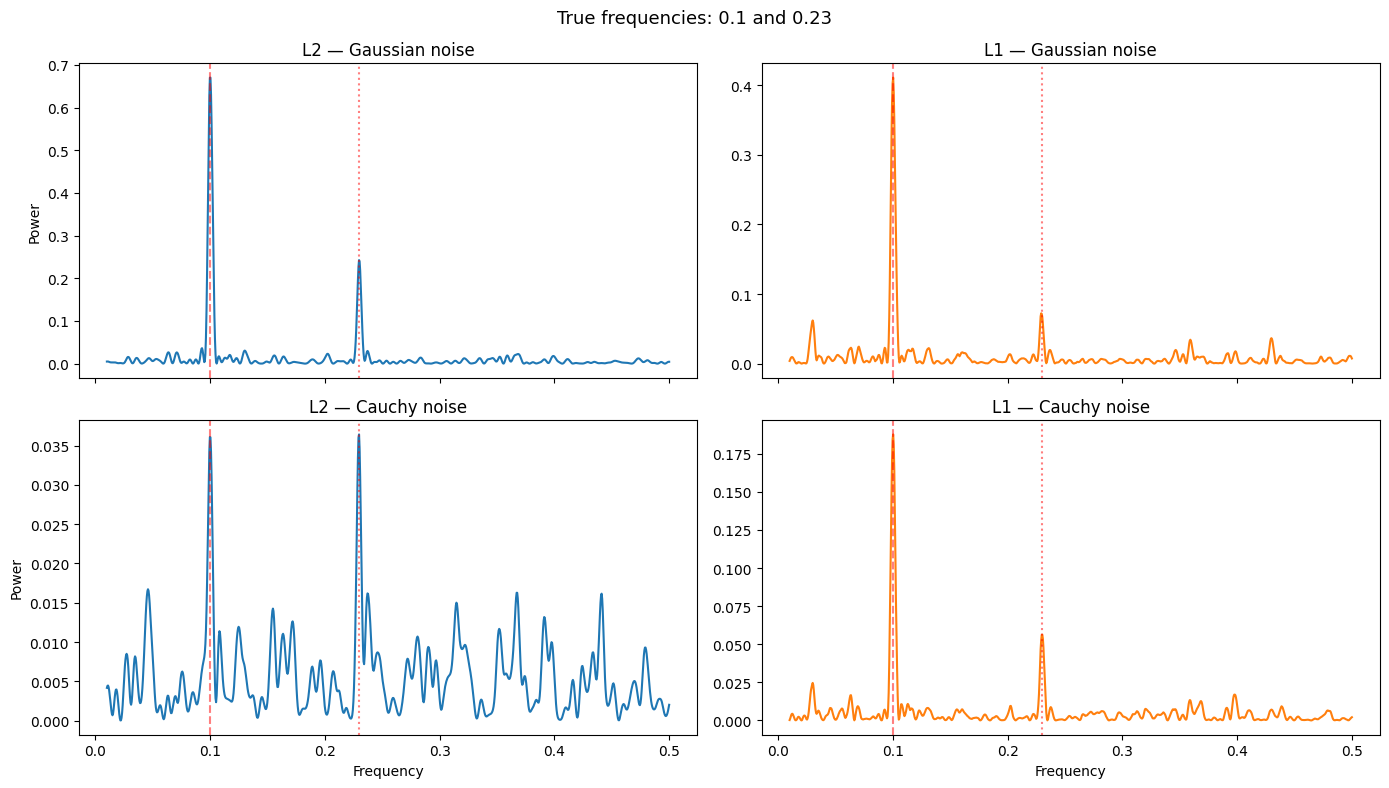

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

# Gaussian noise
axes[0, 0].plot(freq_grid, power_l2, 'C0')
axes[0, 0].axvline(f1, color='r', ls='--', alpha=0.5)
axes[0, 0].axvline(f2, color='r', ls=':', alpha=0.5)
axes[0, 0].set_title('L2 — Gaussian noise')
axes[0, 0].set_ylabel('Power')

axes[0, 1].plot(freq_grid, power_l1, 'C1')
axes[0, 1].axvline(f1, color='r', ls='--', alpha=0.5)
axes[0, 1].axvline(f2, color='r', ls=':', alpha=0.5)
axes[0, 1].set_title('L1 — Gaussian noise')

# Cauchy noise
axes[1, 0].plot(freq_grid, power_l2_c, 'C0')
axes[1, 0].axvline(f1, color='r', ls='--', alpha=0.5)
axes[1, 0].axvline(f2, color='r', ls=':', alpha=0.5)
axes[1, 0].set_title('L2 — Cauchy noise')
axes[1, 0].set_ylabel('Power')
axes[1, 0].set_xlabel('Frequency')

axes[1, 1].plot(freq_grid, power_l1_c, 'C1')
axes[1, 1].axvline(f1, color='r', ls='--', alpha=0.5)
axes[1, 1].axvline(f2, color='r', ls=':', alpha=0.5)
axes[1, 1].set_title('L1 — Cauchy noise')
axes[1, 1].set_xlabel('Frequency')

fig.suptitle(f'True frequencies: {f1} and {f2}', fontsize=13)
plt.tight_layout()

## Best-fit model at detected frequency (Cauchy case)

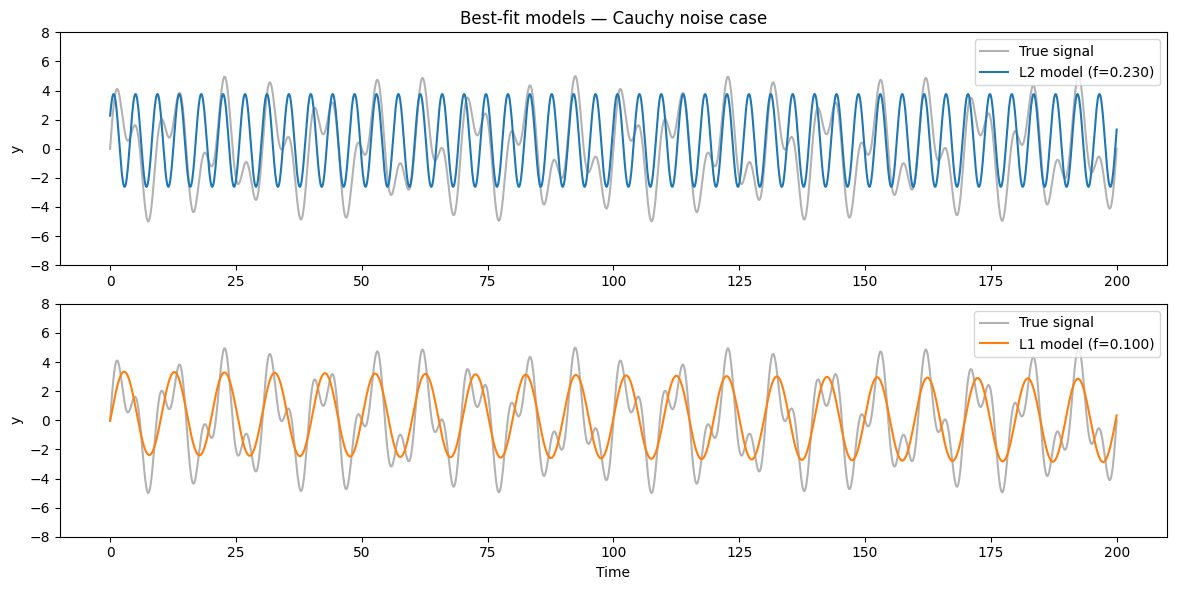

In [19]:
# Best L1 frequency
best_f_l1 = freq_grid[np.argmax(power_l1_c)]
best_f_l2 = freq_grid[np.argmax(power_l2_c)]

y_model_l1 = ls_l1_c.model(t_dense, best_f_l1)
y_model_l2 = ls_l2_c.model(t_dense, best_f_l2)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(t_dense, y_dense, 'k-', alpha=0.3, label='True signal')
axes[0].plot(t_dense, y_model_l2, 'C0-', label=f'L2 model (f={best_f_l2:.3f})')
axes[0].set_ylabel('y')
axes[0].legend()
axes[0].set_title('Best-fit models — Cauchy noise case')
axes[0].set_ylim(-8, 8)

axes[1].plot(t_dense, y_dense, 'k-', alpha=0.3, label='True signal')
axes[1].plot(t_dense, y_model_l1, 'C1-', label=f'L1 model (f={best_f_l1:.3f})')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('y')
axes[1].legend()
axes[1].set_ylim(-8, 8)

plt.tight_layout()

## Bootstrap false alarm levels

Use `false_alarm_level` to determine significance thresholds via bootstrap (shuffle y, recompute max power). This is the only FAP method available for L1, since analytic approximations rely on L2 assumptions.

Peak power: 0.1876 at f=0.1003
Bootstrap FAP of peak: 0.0000


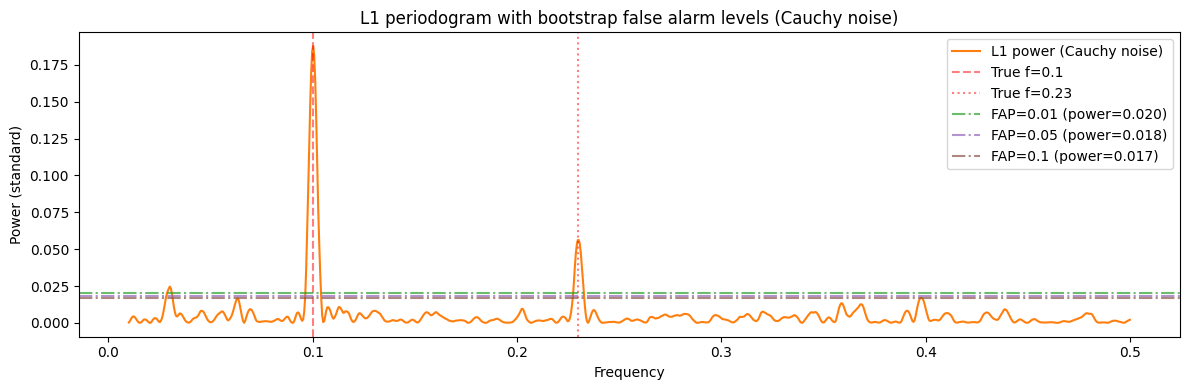

In [20]:
# Bootstrap FAP levels for the Cauchy noise case (L1)
# Coarse grid + parallel jobs for speed (~10ms per LP solve)
freq_boot = np.linspace(0.01, 0.5, 200)

fap_levels = [0.01, 0.05, 0.10]
power_thresholds = ls_l1_c.false_alarm_level(
    fap_levels, n_bootstrap=100, frequency=freq_boot, random_state=42, n_jobs=-1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(freq_grid, power_l1_c, 'C1', label='L1 power (Cauchy noise)')
ax.axvline(f1, color='r', ls='--', alpha=0.5, label=f'True f={f1}')
ax.axvline(f2, color='r', ls=':', alpha=0.5, label=f'True f={f2}')

colors = ['C2', 'C4', 'C5']
for fap, thresh, c in zip(fap_levels, power_thresholds, colors):
    ax.axhline(thresh, color=c, ls='-.', alpha=0.7, label=f'FAP={fap} (power={thresh:.3f})')

ax.set_xlabel('Frequency')
ax.set_ylabel('Power (standard)')
ax.legend(loc='upper right')
ax.set_title('L1 periodogram with bootstrap false alarm levels (Cauchy noise)')
plt.tight_layout()

# Also show the FAP of the actual peak
peak_power = np.max(power_l1_c)
peak_fap = ls_l1_c.false_alarm_probability(
    peak_power, n_bootstrap=100, frequency=freq_boot, random_state=42, n_jobs=-1)
print(f'Peak power: {peak_power:.4f} at f={freq_grid[np.argmax(power_l1_c)]:.4f}')
print(f'Bootstrap FAP of peak: {peak_fap:.4f}')